# Testing — PoseC3D (ciis_7)

Evaluasi model hasil training menggunakan `mmaction2/tools/test.py`.

In [1]:
import os
import glob
import numpy as np
import mmengine

# libraries untuk metrik
from sklearn.metrics import (classification_report, average_precision_score)
from sklearn.preprocessing import label_binarize

import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
from sklearn.metrics import confusion_matrix
from sklearn.metrics import precision_score, recall_score, f1_score

## 1. CONFIG

In [ ]:
# Path konfigurasi
CONFIG     = "01_asset_tools/ciis_7.py"               # config yang dipakai training
WORK_DIR   = "02_work_dirs/<sesuaikan>"               # folder hasil training
DUMP_FILE  = f"{WORK_DIR}/<sesuaikan>.pkl"            # output hasil prediksi
OUTPUT_DIR = f"{WORK_DIR}/output_<sesuaikan>"         # folder simpan gambar metrik

# Path plot
CONF_MATRIX_PATH = f"{OUTPUT_DIR}/confusion_matrix.png"
METRIK_PATH = f"{OUTPUT_DIR}/per_class_metrics.png"
summary_path = f"{OUTPUT_DIR}/test_summary.txt"

os.makedirs(OUTPUT_DIR, exist_ok=True)

# cari checkpoint terbaik
best_ckpts = sorted(glob.glob(f"{WORK_DIR}/best_acc_top1_epoch_*.pth"))
all_ckpts  = sorted(glob.glob(f"{WORK_DIR}/epoch_*.pth"))

if best_ckpts:
    CHECKPOINT = best_ckpts[-1]
    print(f"✓ Best checkpoint ditemukan: {CHECKPOINT}")
elif all_ckpts:
    CHECKPOINT = all_ckpts[-1]
    print(f"⚠ Best checkpoint tidak ada, pakai epoch terakhir: {CHECKPOINT}")
else:
    raise FileNotFoundError(f"Tidak ada checkpoint di {WORK_DIR}")

# Label map
LABEL_MAP_FILE = "03_dataset/ciis_label_map.txt"

def load_label_map(path):
    with open(path) as f:
        lines = f.readlines()
    return {int(x[0]): x[1].strip() for x in [l.strip().split(": ") for l in lines if l.strip()]}

label_map  = load_label_map(LABEL_MAP_FILE)
num_classes = len(label_map)
class_names = [label_map[i] for i in range(num_classes)]
print(f"\nKelas ({num_classes}): {class_names}")

✓ Best checkpoint ditemukan: 02_work_dirs/ciis_7_gab2_2s/best_acc_top1_epoch_230.pth

Kelas (7): ['normal', 'berjongkok', 'merayap', 'membidik senapan', 'membidik pistol', 'memukul', 'menendang']


## 2. TESTING

In [ ]:
!python mmaction2/tools/test.py {CONFIG} {CHECKPOINT} \
    --work-dir {WORK_DIR} \
    --dump {DUMP_FILE}

06/19 18:17:36 - mmengine - INFO - 
------------------------------------------------------------
System environment:
    sys.platform: linux
    Python: 3.8.18 (default, Sep 11 2023, 13:40:15) [GCC 11.2.0]
    CUDA available: True
    MUSA available: False
    numpy_random_seed: 255152351
    GPU 0: NVIDIA GeForce RTX 3090
    CUDA_HOME: /usr/local/cuda-12.3
    NVCC: Cuda compilation tools, release 12.3, V12.3.107
    GCC: gcc (Ubuntu 13.3.0-6ubuntu2~24.04.1) 13.3.0
    PyTorch: 2.2.1
    PyTorch compiling details: PyTorch built with:
  - GCC 9.3
  - C++ Version: 201703
  - Intel(R) oneAPI Math Kernel Library Version 2023.1-Product Build 20230303 for Intel(R) 64 architecture applications
  - Intel(R) MKL-DNN v3.3.2 (Git Hash 2dc95a2ad0841e29db8b22fbccaf3e5da7992b01)
  - OpenMP 201511 (a.k.a. OpenMP 4.5)
  - LAPACK is enabled (usually provided by MKL)
  - NNPACK is enabled
  - CPU capability usage: AVX2
  - CUDA Runtime 12.1
  - NVCC architecture flags: -gencode;arch=compute_50,code=sm

## 3. Load dan parse hasil prediksi

In [3]:
# Load hasil dump
results = mmengine.load(DUMP_FILE)
print(f"Total sample test: {len(results)}")
print(f"Keys dalam satu hasil: {list(results[0].keys())}")

# Ekstrak scores dan ground truth
all_scores = []
all_labels = []

for r in results:
    # pred_scores: probability vector tiap kelas
    scores = r['pred_score']
    if hasattr(scores, 'numpy'):
        scores = scores.numpy()
    all_scores.append(np.array(scores).flatten())

    # gt_labels: ground truth label
    gt = r['gt_label']
    if hasattr(gt, 'numpy'):
        gt = gt.numpy()
    all_labels.append(int(np.array(gt).flatten()[0]))

all_scores = np.array(all_scores)   # shape: [N, num_classes]
all_labels = np.array(all_labels)   # shape: [N]
all_preds  = all_scores.argmax(axis=1)

print(f"\nShape scores : {all_scores.shape}")
print(f"Shape labels : {all_labels.shape}")
print(f"Distribusi kelas ground truth:")
for i, name in enumerate(class_names):
    count = (all_labels == i).sum()
    print(f"  [{i}] {name:20s}: {count} sample")


Total sample test: 840
Keys dalam satu hasil: ['num_classes', 'img_shape', 'pred_score', 'gt_label', 'pred_label']

Shape scores : (840, 7)
Shape labels : (840,)
Distribusi kelas ground truth:
  [0] normal              : 120 sample
  [1] berjongkok          : 120 sample
  [2] merayap             : 120 sample
  [3] membidik senapan    : 120 sample
  [4] membidik pistol     : 120 sample
  [5] memukul             : 120 sample
  [6] menendang           : 120 sample


## 4. Metrik utama

In [ ]:
# Top-1 Accuracy
top1 = (all_preds == all_labels).mean()

# Top-5 Accuracy
top5_correct = sum(
    all_labels[i] in np.argsort(all_scores[i])[-5:]
    for i in range(len(all_labels))
)
top5 = top5_correct / len(all_labels)

# Mean Class Accuracy (acc/mean1)
per_class_acc = []
for i in range(num_classes):
    mask = all_labels == i
    if mask.sum() == 0:
        continue
    per_class_acc.append((all_preds[mask] == all_labels[mask]).mean())
mean1 = np.mean(per_class_acc)

# mAP
y_bin = label_binarize(all_labels, classes=list(range(num_classes)))
mAP   = average_precision_score(y_bin, all_scores, average='macro')

# Per-class AP
per_class_ap = average_precision_score(y_bin, all_scores, average=None)

print("=" * 55)
print("  HASIL TESTING")
print("=" * 55)
print(f"  Top-1 Accuracy  : {top1:.4f}  ({top1*100:.2f}%)")
print(f"  Top-5 Accuracy  : {top5:.4f}  ({top5*100:.2f}%)")
print(f"  Mean Class Acc  : {mean1:.4f}  ({mean1*100:.2f}%)")
print(f"  mAP (macro)     : {mAP:.4f}  ({mAP*100:.2f}%)")
print("=" * 55)
print()
print("[ Per-class Average Precision ]")
for i, name in enumerate(class_names):
    print(f"  [{i}] {name:20s}: AP = {per_class_ap[i]:.4f}")
print()

# Classification Report (Precision, Recall, F1)
print("[ Classification Report ]")
print(classification_report(all_labels, all_preds, target_names=class_names))


  HASIL TESTING
  Top-1 Accuracy  : 0.7750  (77.50%)
  Top-5 Accuracy  : 0.9917  (99.17%)
  Mean Class Acc  : 0.7750  (77.50%)
  mAP (macro)     : 0.8720  (87.20%)

[ Per-class Average Precision ]
  [0] normal              : AP = 0.8783
  [1] berjongkok          : AP = 0.9724
  [2] merayap             : AP = 0.9725
  [3] membidik senapan    : AP = 0.6978
  [4] membidik pistol     : AP = 0.8338
  [5] memukul             : AP = 0.8613
  [6] menendang           : AP = 0.8880

[ Classification Report ]
                  precision    recall  f1-score   support

          normal       0.89      0.57      0.69       120
      berjongkok       0.87      0.95      0.91       120
         merayap       0.86      0.96      0.91       120
membidik senapan       0.77      0.51      0.61       120
 membidik pistol       0.69      0.82      0.75       120
         memukul       0.84      0.71      0.77       120
       menendang       0.62      0.92      0.74       120

        accuracy              

## 5. Confusion Matrix

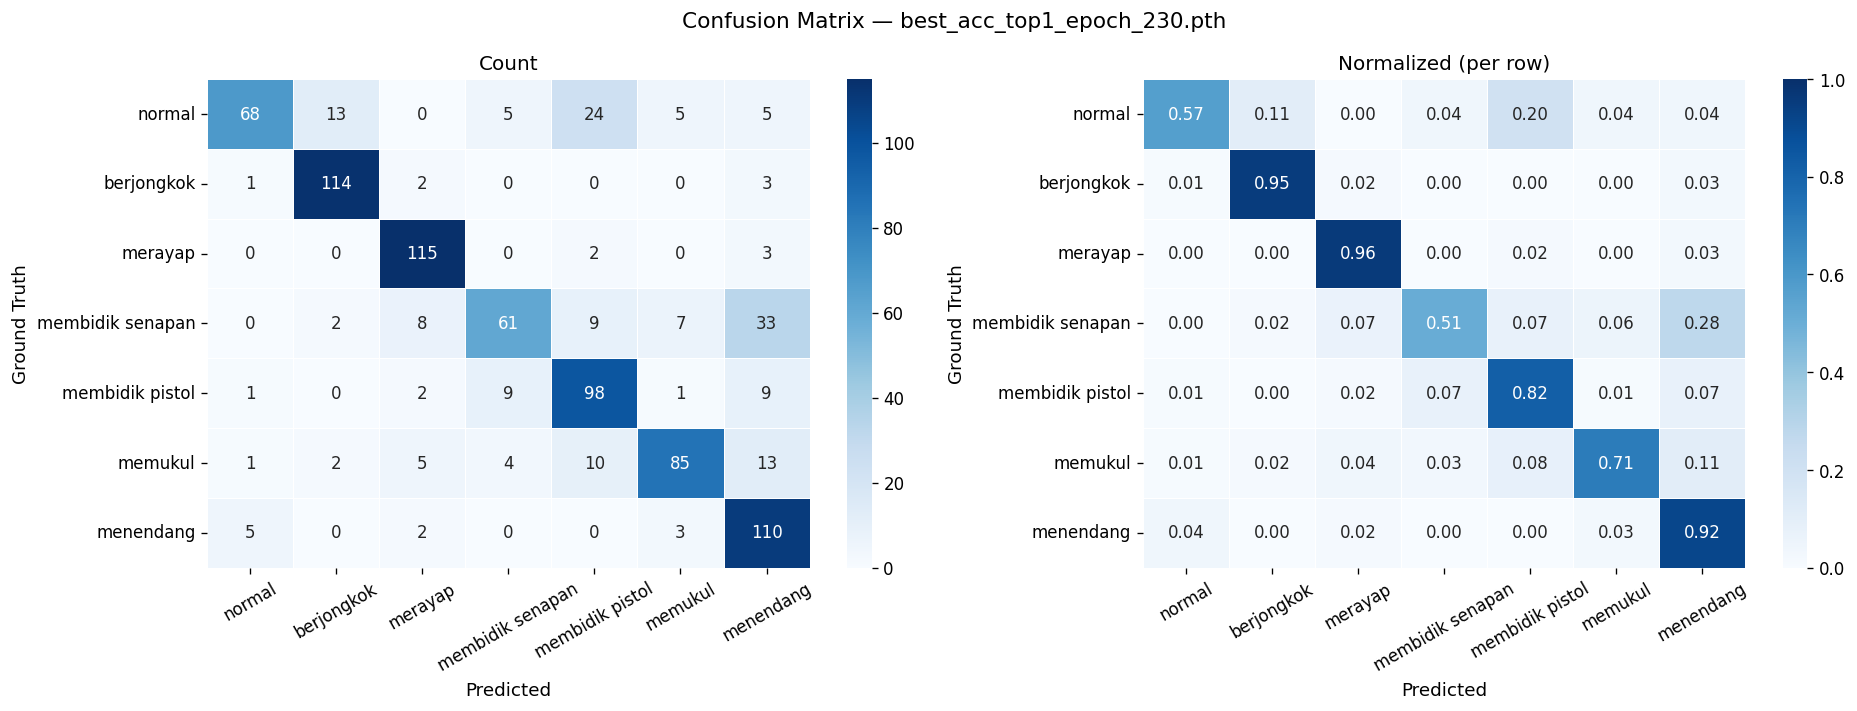

Disimpan: 02_work_dirs/ciis_7_gab2_2s/testyolo11_output/confusion_matrix.png


In [ ]:
matplotlib.rcParams['figure.dpi'] = 120

cm      = confusion_matrix(all_labels, all_preds)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)  # normalized per baris

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(f"Confusion Matrix — {os.path.basename(CHECKPOINT)}", fontsize=13)

# Kiri: count
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            ax=axes[0], linewidths=0.5)
axes[0].set_xlabel('Predicted', fontsize=11)
axes[0].set_ylabel('Ground Truth', fontsize=11)
axes[0].set_title('Count')
axes[0].tick_params(axis='x', rotation=30)
axes[0].tick_params(axis='y', rotation=0)

# Kanan: normalized (%)
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            ax=axes[1], linewidths=0.5, vmin=0, vmax=1)
axes[1].set_xlabel('Predicted', fontsize=11)
axes[1].set_ylabel('Ground Truth', fontsize=11)
axes[1].set_title('Normalized (per row)')
axes[1].tick_params(axis='x', rotation=30)
axes[1].tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig(CONF_MATRIX_PATH, dpi=300, bbox_inches='tight')
plt.show()
print(f"Disimpan: {CONF_MATRIX_PATH}")

## 6. Plot per-class metrik

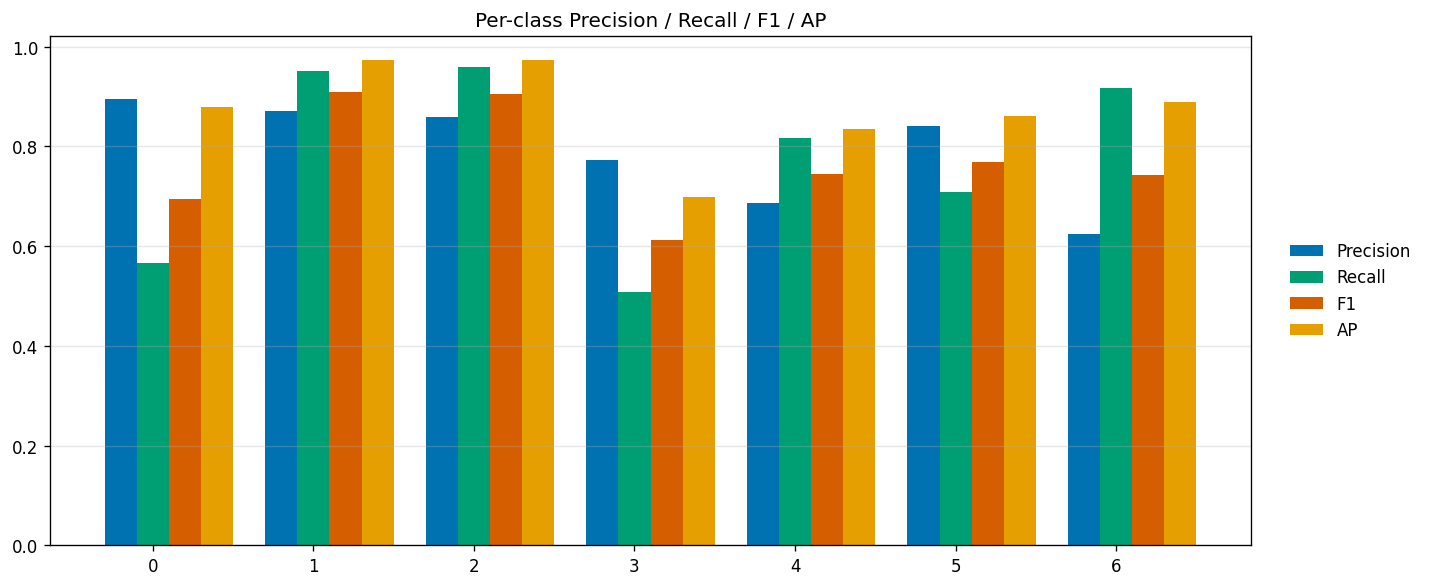

Disimpan: 02_work_dirs/ciis_7_gab2_2s/testyolo11_output/per_class_metrics.png


In [ ]:
precision = precision_score(all_labels, all_preds, average=None, zero_division=0)
recall = recall_score(all_labels, all_preds, average=None, zero_division=0)
f1 = f1_score(all_labels, all_preds, average=None, zero_division=0)

x = np.arange(num_classes)
w = 0.2

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - w,   precision,    w, label='Precision', color='#0072b2')
ax.bar(x,       recall,       w, label='Recall',    color='#009e73')
ax.bar(x + w,   f1,           w, label='F1',        color='#d55e00')
ax.bar(x + 2*w, per_class_ap, w, label='AP',        color='#e69f00')
ax.set_title('Per-class Precision / Recall / F1 / AP')
ax.legend(
    loc='center left',
    bbox_to_anchor=(1.02, 0.5),
    frameon=False)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()

plt.savefig(METRIK_PATH, dpi=300, bbox_inches='tight')
plt.show()
print(f"Disimpan: {METRIK_PATH}")

## 7. Simpan ringkasan hasil ke teks

In [ ]:
with open(summary_path, 'w') as f:
    f.write(f"CONFIG    : {CONFIG}\n")
    f.write(f"CHECKPOINT: {CHECKPOINT}\n")
    f.write(f"DUMP FILE : {DUMP_FILE}\n")
    f.write(f"Jumlah sample test: {len(results)}\n\n")
    f.write("=" * 55 + "\n")
    f.write("HASIL TESTING\n")
    f.write("=" * 55 + "\n")
    f.write(f"Top-1 Accuracy  : {top1:.4f}  ({top1*100:.2f}%)\n")
    f.write(f"Top-5 Accuracy  : {top5:.4f}  ({top5*100:.2f}%)\n")
    f.write(f"Mean Class Acc  : {mean1:.4f}  ({mean1*100:.2f}%)\n")
    f.write(f"mAP (macro)     : {mAP:.4f}  ({mAP*100:.2f}%)\n\n")
    f.write("Per-class AP:\n")
    for i, name in enumerate(class_names):
        f.write(f"  [{i}] {name:20s}: {per_class_ap[i]:.4f}\n")
    f.write("\n")
    from sklearn.metrics import classification_report
    f.write(classification_report(all_labels, all_preds, target_names=class_names))

print(f"Ringkasan disimpan: {summary_path}")
print()

# Tampilkan isi ringkasan
with open(summary_path) as f:
    print(f.read())

Ringkasan disimpan: 02_work_dirs/ciis_7_gab2_2s/testyolo11_output/test_summary.txt

CONFIG    : 01_asset_tools/ciis_7.py
CHECKPOINT: 02_work_dirs/ciis_7_gab2_2s/best_acc_top1_epoch_230.pth
DUMP FILE : 02_work_dirs/ciis_7_gab2_2s/test_resultyolo11.pkl
Jumlah sample test: 840

HASIL TESTING
Top-1 Accuracy  : 0.7750  (77.50%)
Top-5 Accuracy  : 0.9917  (99.17%)
Mean Class Acc  : 0.7750  (77.50%)
mAP (macro)     : 0.8720  (87.20%)

Per-class AP:
  [0] normal              : 0.8783
  [1] berjongkok          : 0.9724
  [2] merayap             : 0.9725
  [3] membidik senapan    : 0.6978
  [4] membidik pistol     : 0.8338
  [5] memukul             : 0.8613
  [6] menendang           : 0.8880

                  precision    recall  f1-score   support

          normal       0.89      0.57      0.69       120
      berjongkok       0.87      0.95      0.91       120
         merayap       0.86      0.96      0.91       120
membidik senapan       0.77      0.51      0.61       120
 membidik pistol  